In [2]:
1250080179 % 31

2

In [2]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import MeanShift, KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load data

In [60]:
df = pd.read_csv('data/babies.csv')
df.head(n = 2)

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0


# Check null

In [61]:
df.isna().sum()

case          0
bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

# Preprocessing

## Remove <b>case<b>

In [62]:
df.drop(columns='case', inplace= True)
df.head(n=2)

,bwt,gestation,parity,age,height,weight,smoke
0,120,284.0,0,27.0,62.0,100.0,0.0
1,113,282.0,0,33.0,64.0,135.0,0.0


## Drop NaN

In [63]:
df = df.dropna().copy()
df.head(n=2)

,bwt,gestation,parity,age,height,weight,smoke
0,120,284.0,0,27.0,62.0,100.0,0.0
1,113,282.0,0,33.0,64.0,135.0,0.0


## Check null

In [64]:
df.isna().sum()

bwt          0
gestation    0
parity       0
age          0
height       0
weight       0
smoke        0
dtype: int64

## Preprocessing Standard Scale

In [65]:
cols_cont = ['age', 'height', 'weight']
standard = StandardScaler()
df[['ageScale', 'heightScale', 'weightScale']] = standard.fit_transform(df[cols_cont])

### Sampling

In [66]:
df = df.sample(n=100, random_state=2026)

In [67]:
X = df[['heightScale', 'weightScale']]
for bw in np.linspace(0.7, 2, 10):
    ms = MeanShift(bandwidth=bw)
    ms.fit(X)
    print(bw, np.unique(ms.labels_))

0.7 [0 1 2 3 4 5 6 7]
0.8444444444444444 [0 1 2 3 4 5]
0.9888888888888889 [0 1 2 3]
1.1333333333333333 [0 1 2]
1.2777777777777777 [0 1 2]
1.4222222222222223 [0 1]
1.5666666666666667 [0 1]
1.7111111111111112 [0 1]
1.8555555555555556 [0 1]
2.0 [0]


In [68]:
ms = MeanShift(bandwidth=0.85)
X = df[['heightScale', 'weightScale']]
ms.fit(X)
df['Mean Shift Cluster Scale'] = ms.labels_

In [69]:
X = df[['ageScale', 'heightScale', 'weightScale']]
for bw in np.linspace(0.9, 2, 10):
    ms = MeanShift(bandwidth=bw)
    ms.fit(X)
    print(bw, np.unique(ms.labels_))

0.9 [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
1.0222222222222221 [0 1 2 3 4 5 6 7]
1.1444444444444444 [0 1 2 3 4 5 6]
1.2666666666666666 [0 1 2 3 4]
1.3888888888888888 [0 1 2 3]
1.511111111111111 [0 1 2]
1.6333333333333333 [0 1]
1.7555555555555555 [0 1]
1.8777777777777778 [0 1]
2.0 [0 1]


In [70]:
ms = MeanShift(bandwidth=1.1)
X = df[['ageScale', 'heightScale', 'weightScale']]
ms.fit(X)
df['Mean Shift Cluster With age Scale'] = ms.labels_

In [71]:
dic = {
    'Mean Shift Cluster Scale': df[['heightScale', 'weightScale']],
    'Mean Shift Cluster With age Scale': df[['ageScale', 'heightScale', 'weightScale']]
}
result = []
for name in dic:
    score = silhouette_score(dic[name], df[name])
    result.append({'Title': name, 'Silhouette Score': score})
pd.DataFrame(result)

,Title,Silhouette Score
0,Mean Shift Cluster Scale,0.336271
1,Mean Shift Cluster With age Scale,0.304363


# Mean Shift vs KMean vs AgglomerativeClustering

In [38]:
df.columns

Index(['bwt', 'gestation', 'parity', 'age', 'height', 'weight', 'smoke',
       'ageScale', 'heightScale', 'weightScale', 'Mean Shift Cluster Scale',
       'Mean Shift Cluster With age Scale'],
      dtype='object')

In [72]:
X = df[['heightScale', 'weightScale']]
models = {
    'Mean Shift': MeanShift(bandwidth=1.5),
    'K-Means': KMeans(n_clusters=5),
    'Agglomerative': AgglomerativeClustering(n_clusters=5)
}
result = []
for name in models:
    models[name].fit(X)
    result.append({
        'Model': name,
        'Silhouette Score': silhouette_score(X, models[name].labels_)
    })
pd.DataFrame(result)

,Model,Silhouette Score
0,Mean Shift,0.504470
1,K-Means,0.315410
2,Agglomerative,0.386458


## Hierachy Cluster

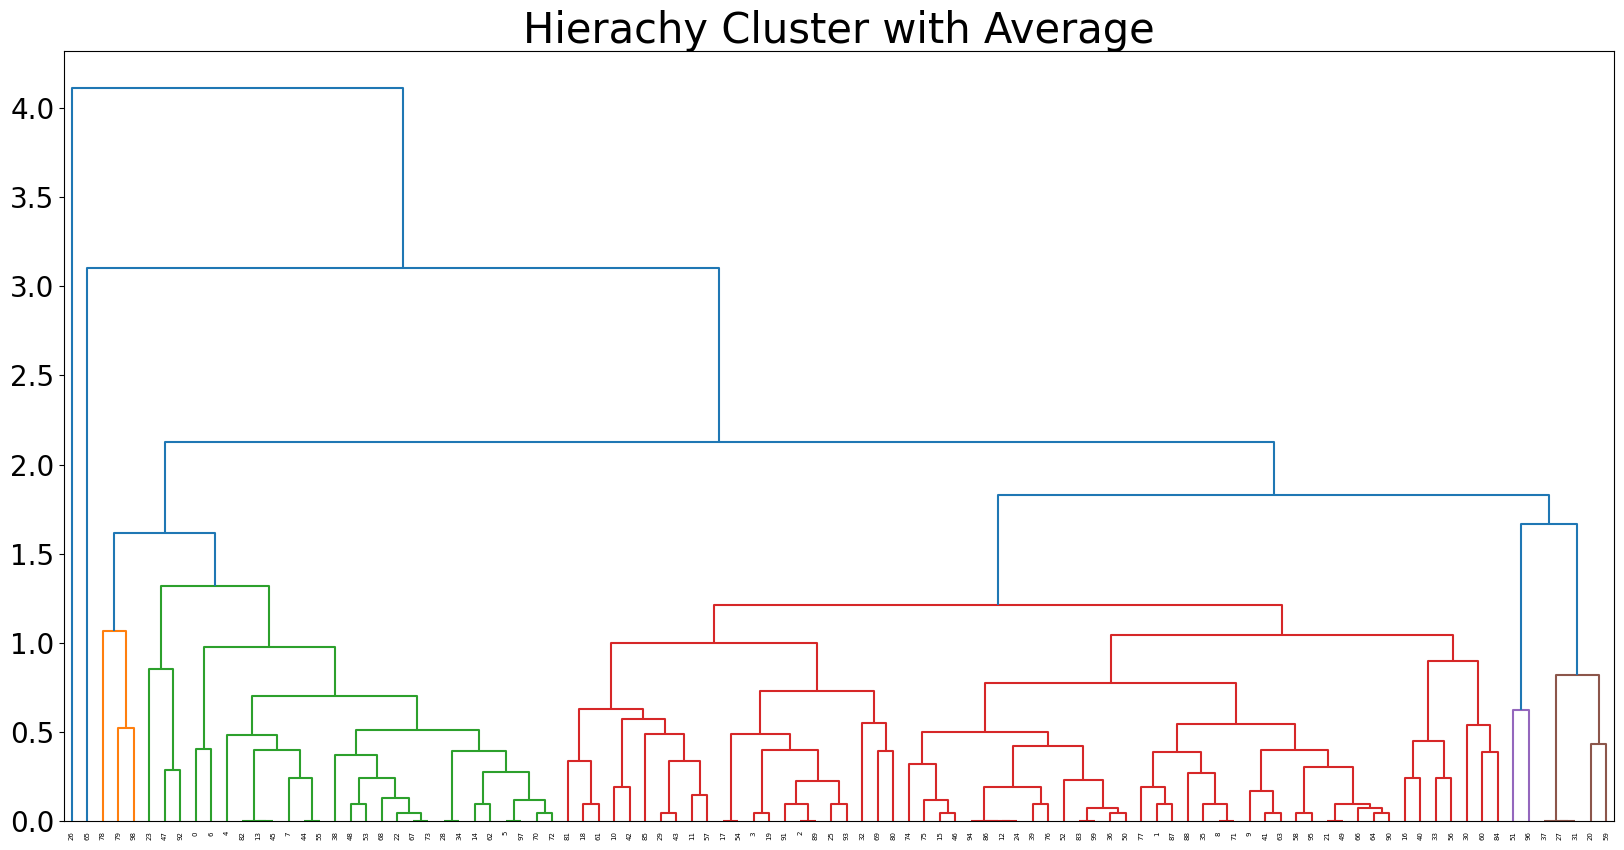

In [83]:
lk = linkage(X, method='average')
plt.figure(figsize=(20,10))
dendrogram(lk, p=5, color_threshold=1.5)
plt.title('Hierachy Cluster with Average', fontsize=30)
plt.yticks(fontsize=20)
plt.show()

### KMeans

In [84]:
scores = {'inertia': [], 'silhouette': []}
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    scores['inertia'].append(kmeans.inertia_)
    scores['silhouette'].append(silhouette_score(X, kmeans.labels_))

### Ebow method vs Silhouette score

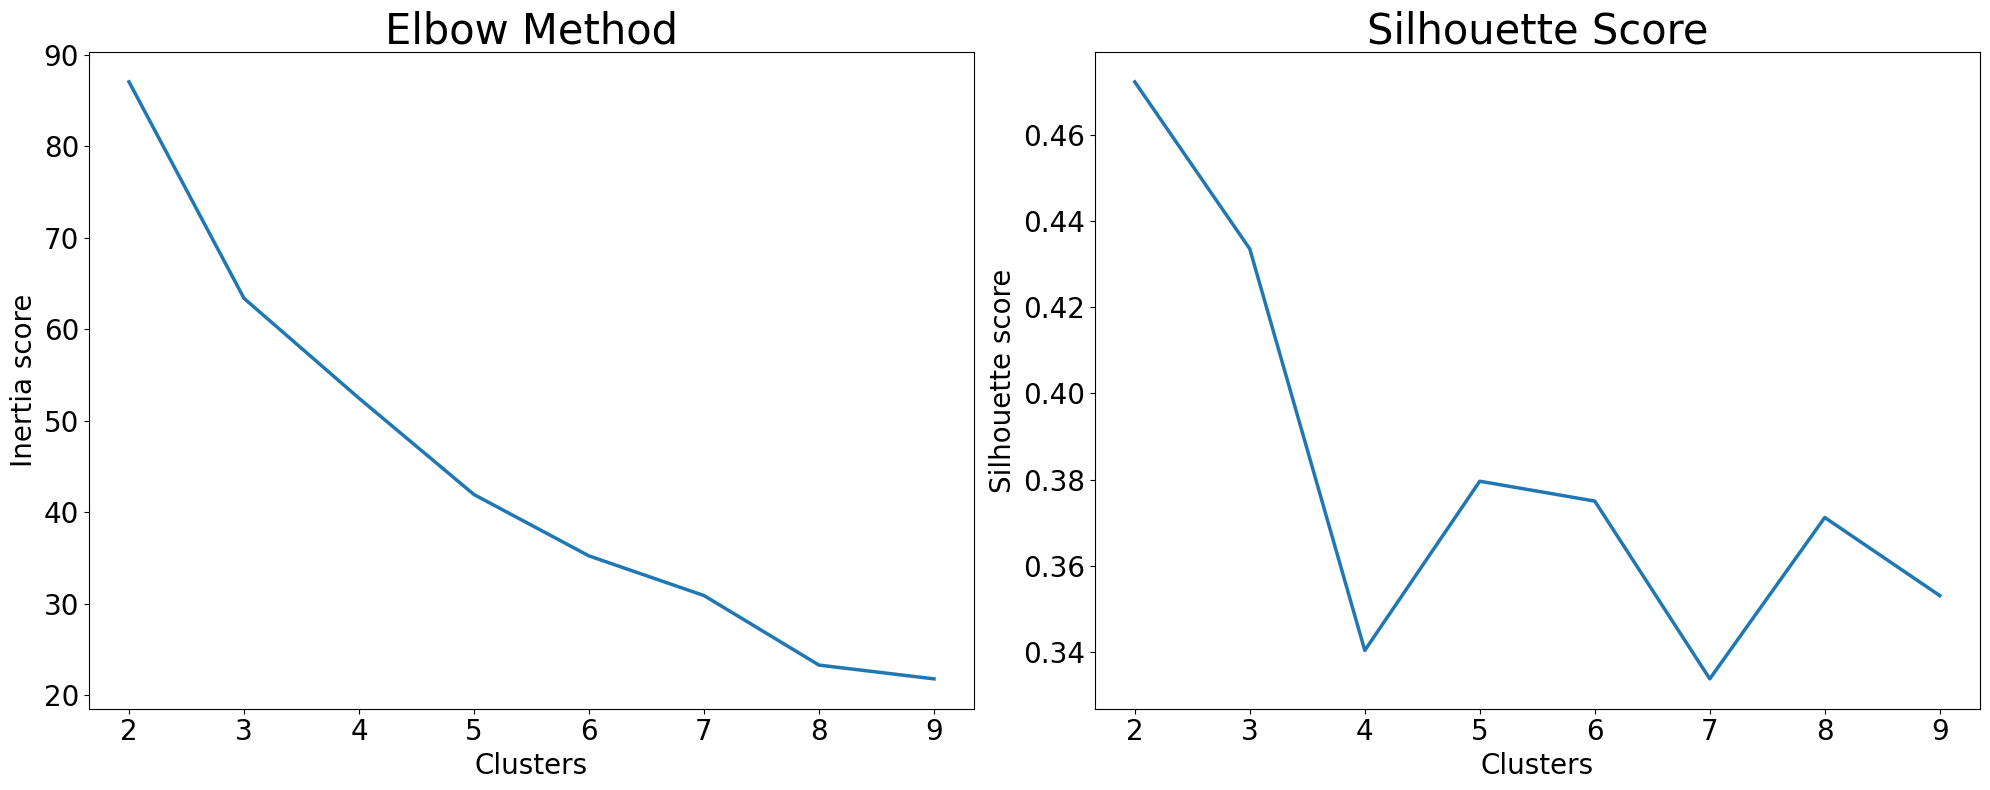

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(20, 8))
axes[0].set_title('Elbow Method', fontsize=30)
axes[0].set_xlabel('Clusters', fontsize=20)
axes[0].set_ylabel('Inertia score', fontsize=20)
axes[0].tick_params(axis='both', labelsize=20)
axes[1].plot(range(2, 10), scores['silhouette'], linewidth=2.5)
axes[1].set_title('Silhouette Score', fontsize=30)
axes[1].set_xlabel('Clusters', fontsize=20)
axes[1].set_ylabel('Silhouette score', fontsize=20)
axes[1].tick_params(axis='both', labelsize=20)
plt.tight_layout()
plt.show()